In [1]:
!pip install xlrd
!pip install openpyxl
import pandas as pd
import unicodedata
from pathlib import Path

### Importation données listes municipales 2014

In [2]:
#creation d'une fonction pour détecter là où débute vraiment le fichier
def detecter_ligne_header(fichier, mot_cle="Critère d'export", limite=15):
    preview = pd.read_excel(fichier, header=None, nrows=limite)

    for idx, row in preview.iterrows():
        if mot_cle in row.astype(str).values:
            return idx
    return 0

In [3]:
# Dossier contenant uniquement les fichiers à importer
dossier = Path("/home/onyxia/work/projet3A/donnees_electorales/donnees listes municipales 2014")

# Liste de tous les fichiers du dossier
fichiers = dossier.iterdir()

dfs = []

for f in fichiers:
    ligne_header = detecter_ligne_header(f)
    df = pd.read_excel(f, header=ligne_header)
    df["source"] = f.name  # optionnelle
    dfs.append(df)
    print(df.shape)

df_listes_muni_2014 = pd.concat(dfs, ignore_index=True)

# Aperçu
print(df_listes_muni_2014.head())
print("Dimensions :", df_listes_muni_2014.shape)

# Sauvegarde (optionnelle)
#df_listes_muni_2014.to_excel("/home/onyxia/work/projet3A/donnees_electorales/all_listes_municipales_2014.xlsx", index=False)

(53666, 16)
(13752, 16)
(33789, 16)
(5807, 16)
(11873, 16)
(3454, 16)
(8671, 16)
(5301, 16)
(14266, 16)
(2433, 16)
(27600, 16)
(27657, 16)
(31172, 16)
(3515, 16)
(8521, 16)
(20320, 16)
(11550, 16)
(27843, 16)
(15857, 16)
(22391, 16)
(16522, 16)
(2765, 16)
(40382, 16)
(37305, 16)
(1566, 16)
(22542, 16)
(36763, 16)
(12791, 16)
          Critère d'export Code du département Libellé du département  \
0  Région 82 - RHONE-ALPES                   1                    AIN   
1  Région 82 - RHONE-ALPES                   1                    AIN   
2  Région 82 - RHONE-ALPES                   1                    AIN   
3  Région 82 - RHONE-ALPES                   1                    AIN   
4  Région 82 - RHONE-ALPES                   1                    AIN   

  Code commune    Libellé commune  N° Panneau Liste  Code Dépôt  \
0            4  Ambérieu-en-Bugey               1.0           3   
1            4  Ambérieu-en-Bugey               1.0           3   
2            4  Ambérieu-en-Bugey

In [4]:
df_listes_muni_2014.drop(labels = [ "Critère d'export", 'Libellé du département','Libellé commune', 'N° Panneau Liste', 'Code Dépôt',
       'Libellé abrégé liste', 'Libellé Etendu Liste',
       'Sexe', 'Nationalité',
       'Candidat au conseil communautaire', 'source'],axis = 1, inplace=True)

In [5]:
df_listes_muni_2014.columns

Index(['Code du département', 'Code commune', 'N° du candidat dans la liste',
       'Nom', 'Prénom'],
      dtype='object')

Importation des données de toutes les élections

In [6]:
all_elections = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/candidats_results.txt", sep=";")
#mini modif manuelle à cause d'une erreur
all_elections.loc[22340396, 'Binôme'] = all_elections.loc[22160435, 'Binôme']

/tmp/ipykernel_267391/3451900702.py:1: DtypeWarning: Columns (2,4,6,7,8,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  all_elections = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/candidats_results.txt", sep=";")


In [7]:
muni_2014 = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/MN14_Bvot_T1T2.txt", sep=";",
    encoding="latin-1", skiprows=17, header= None)
muni_2014.columns = ['id_tour', 'Code du département', 'Code de la commune', 'Nom de la commune',
'Code du b.vote', 'Inscrits', 'Votants', 'Exprimes', 'num liste', 'Prénom', 'Nom', 'Nuance', 'Voix']
muni_2014['id_tour'] = "t" + muni_2014['id_tour'].astype(str)

/tmp/ipykernel_267391/1504886825.py:1: DtypeWarning: Columns (1,4) have mixed types. Specify dtype option on import or set low_memory=False.
  muni_2014 = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/MN14_Bvot_T1T2.txt", sep=";",


In [8]:
def simplifier_prenom(text):
    if pd.isna(text):
        return None   # ou "" ou text
    # Normalise en forme NFD (décompose les accents)
    text_normalized = unicodedata.normalize('NFD', text)
    # Garde seulement les caractères ASCII (supprime les accents)
    text_ascii = text_normalized.encode('ascii', 'ignore').decode('utf-8')
    text_clean = text_ascii.replace('-', ' ')
    return text_clean

## Etape initiale : constituer une liste des nuances de tous les candidats

##### Traitement des données des candidats aux départementales, qui ont un format "binome"

In [9]:
elec_binome = all_elections[all_elections["Binôme"].notna()]
liste_elec_binome = elec_binome['id_election'].unique()
election_dep = all_elections[all_elections['id_election'].isin(liste_elec_binome)]
election_dep.drop_duplicates(subset=["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"], inplace=True)
election_dep = election_dep[["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"]]
election_dep[["candidat1", "candidat2"]] = election_dep["Binôme"].str.split(" et ", expand=True)

# Enlever les titres "M" ou "Mme" au début
election_dep["candidat1"] = election_dep["candidat1"].str.replace(r"^(M\.|Mme)\s+", "", regex=True)
election_dep["candidat2"] = election_dep["candidat2"].str.replace(r"^(M\.|Mme)\s+", "", regex=True)

election_dep[[ "nom1", "prenom1"]] = election_dep["candidat1"].str.split(" ", n=1, expand=True)
election_dep["prenom1"] = election_dep["prenom1"].str.lower()
election_dep[[ "nom2","prenom2"]] = election_dep["candidat2"].str.split(" ", n=1, expand=True)
election_dep["prenom2"] = election_dep["prenom2"].str.lower()

election_dep_long = pd.wide_to_long(election_dep, 
                          stubnames=["prenom", "nom"], 
                          i=["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"], 
                          j="num_binôme",   # nouveau suffixe qui indiquera 1 ou 2
                          sep="")    # pas de séparateur entre stubname et numéro

# Réinitialiser l'index pour obtenir un DataFrame classique
election_dep_long = election_dep_long.reset_index()
election_dep_long['Nuance'] = election_dep_long['Nuance'].str.replace(r'^BC-', '', regex=True)
election_dep_long.drop(['Binôme', 'num_binôme', 'candidat1', 'candidat2'], axis = 1, inplace= True)

/tmp/ipykernel_267391/678289474.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  election_dep.drop_duplicates(subset=["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"], inplace=True)


##### Traitement des candidats hors municipales et départementales

In [10]:
election_hors_dep = all_elections[~all_elections['id_election'].isin(liste_elec_binome)]
election_hors_dep_et_muni = election_hors_dep[election_hors_dep["id_election"].str.contains("muni", case=False, na=False)]
election_hors_dep_et_muni = election_hors_dep_et_muni[['id_election', 'id_brut_miom', 'Code du département', 'Nom', 'Prénom', 'Nuance']]

In [11]:
election_dep_long.rename(columns={'prenom': 'Prénom'}, inplace=True)
election_dep_long.rename(columns={'nom': 'Nom'}, inplace=True)
election_dep_long.rename(columns={'Code du département': 'dep'}, inplace=True)
election_hors_dep_et_muni.rename(columns={'Code du département': 'dep'}, inplace=True)
liste_candidats_nuance_hors_muni = pd.concat([election_dep_long, election_hors_dep_et_muni], ignore_index=True)
liste_candidats_nuance_hors_muni['annee'] = liste_candidats_nuance_hors_muni['id_election'].str[:4]
liste_candidats_nuance_hors_muni.head()

,id_election,id_brut_miom,dep,Nuance,Prénom,Nom,annee
0,2021_dpmt_t2,01001_0001,01,UCD,patricia,CHMARA,2021
1,2021_dpmt_t2,01001_0001,01,UCD,patrick,MATHIAS,2021
2,2021_dpmt_t2,01002_0001,01,UG,fabrice,PEREYRON,2021
3,2021_dpmt_t2,01002_0001,01,UG,marie-céline,RAY,2021
4,2021_dpmt_t2,01004_0001,01,UG,fabrice,PEREYRON,2021


### On s'intéresse au score des municipales

In [12]:
muni_2014['id_brut_miom'] = muni_2014['Code du département'].astype(str) + muni_2014['Code de la commune'].astype(str) + "_" + muni_2014['Code du b.vote'].astype(str)
muni_2014['id_election'] = "2014_muni_" + muni_2014['id_tour'].astype(str)
muni_2014['ident_election_ville'] = muni_2014["id_brut_miom"].str[:-5]

In [13]:
donnees_restreintes_muni = all_elections[all_elections["id_election"].str.contains("muni", case=False, na=False)]
donnees_restreintes_muni['ident_election_ville'] = donnees_restreintes_muni["id_brut_miom"].str[:5]

donnees_muni = pd.concat([donnees_restreintes_muni,muni_2014])

/tmp/ipykernel_267391/3570909418.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  donnees_restreintes_muni['ident_election_ville'] = donnees_restreintes_muni["id_brut_miom"].str[:5]


In [14]:
# ---- Étape 1 : calcul des voix totales par élection et ville ----
voix_totales = (
    donnees_muni
    .groupby(["id_election", "ident_election_ville"], as_index=False)
    .agg(voix_total_ville_elec=("Voix", "sum"))
)

In [15]:
# ---- Étape 2 : calcul des voix par candidat ----
donnees_muni_long = (
    donnees_muni
    .groupby(["id_election", "ident_election_ville", "Nom", "Prénom", "Nuance"], as_index=False)
    .agg(voix_totales_candidat=("Voix", "sum"))
    .merge(voix_totales, on=["id_election", "ident_election_ville"], how="left")
    .assign(voix_pct=lambda d: d["voix_totales_candidat"] / d["voix_total_ville_elec"] * 100)
    .sort_values(["id_election", "ident_election_ville", "voix_pct"], ascending=[True, True, False])
)

# ---- Étape 3 : classement des deux premiers ----
donnees_muni_wide = (
    donnees_muni_long
    .assign(rang=lambda d: d.groupby(["id_election", "ident_election_ville"]).cumcount() + 1)
    .query("rang <= 2")
    .pivot(index=["id_election", "ident_election_ville"],
           columns="rang",
           values=["Prénom", "Nom", "Nuance","voix_pct"])
)

# Aplatir les noms de colonnes hiérarchiques comme "rang1_Prénom"
donnees_muni_wide.columns = [
    f"rang{r}_{v}" for v, r in donnees_muni_wide.columns
]
donnees_muni_wide = donnees_muni_wide.reset_index()

# ---- Étape 5 : extraire les variables election / tour ----
donnees_muni_wide = (
    donnees_muni_wide
    .assign(
        election=lambda d: d["id_election"].str[:9],
        tour=lambda d: d["id_election"].str[10:12])
    .groupby(["election", "ident_election_ville"], group_keys=False)
    .filter(lambda g: not ("t1" in g["tour"].values and "t2" in g["tour"].values and g["tour"].eq("t1").any()))
)


In [55]:
donnees_muni_long.tail()

,id_election,ident_election_ville,Nom,Prénom,Nuance_muni,voix_totales_candidat,voix_total_ville_elec,voix_pct,annee
1418938,2020_muni_t2,ZP755,BRANDER,Astrid,NC,17.0,2221.0,0.765421,2020
1418951,2020_muni_t2,ZP755,KAMAKE,Erevita,NC,5.0,2221.0,0.225124,2020
1418958,2020_muni_t2,ZP755,MATEROURU,"Victor, Tane",NC,2.0,2221.0,0.090050,2020
1418973,2020_muni_t2,ZP758,BROTHERSON,Matahi,LDVD,1381.0,2752.0,50.181686,2020
1418974,2020_muni_t2,ZP758,TEROOATEA,Sylviane,LDVD,1371.0,2752.0,49.818314,2020


<Axes: >

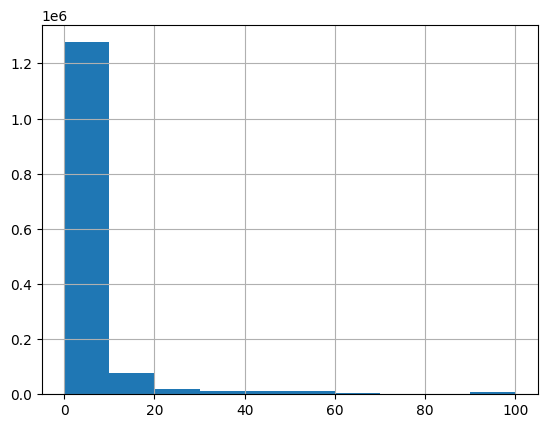

In [54]:
donnees_muni_long['voix_pct'].hist()

In [17]:
#on prépare la suite en créant un fichier listant les têtes de liste des municipales et leur couleur politique
liste_candidats_nuance_muni = (
                    donnees_muni_long
                    .assign(annee = lambda d : d["id_election"].str[0:4])
                    .assign(dep = lambda d : d["ident_election_ville"].str[0:2])
                    .loc[:, ["id_election", "ident_election_ville","annee","dep", "Nom", "Prénom", "Nuance"]]
)
liste_candidats_nuance_muni.head()


,id_election,ident_election_ville,annee,dep,Nom,Prénom,Nuance
1,2008_muni_t1,01004,2008,01,EXPOSITO,Josiane,LUG
0,2008_muni_t1,01004,2008,01,CASTELLANO,Sandrine,LDVD
2,2008_muni_t1,01004,2008,01,PAVIER,Bernard,LGC
3,2008_muni_t1,01004,2008,01,SASSO,Jean-Marc,LDVD
5,2008_muni_t1,01014,2008,01,MAISSIAT,Liliane,LMAJ


In [18]:
df_listes_muni_2014.head()
df_listes_muni_2014['ident_election_ville'] = df_listes_muni_2014['Code du département'].astype(str).str.zfill(2) + df_listes_muni_2014['Code commune'].astype(str).str.zfill(3)


In [19]:
df_listes_muni_2014.columns

Index(['Code du département', 'Code commune', 'N° du candidat dans la liste',
       'Nom', 'Prénom', 'ident_election_ville'],
      dtype='object')

In [20]:
# Harmonisation de sécurité (évite erreurs minuscules/majuscules/espaces)
for col in ["ident_election_ville", "Nom", "Prénom"]:
    df_listes_muni_2014[col] = df_listes_muni_2014[col].astype(str).str.strip().str.upper()
    liste_candidats_nuance_muni[col] = liste_candidats_nuance_muni[col].astype(str).str.strip().str.upper()

# On récupère uniquement les têtes (ordre = 1)
tetes_listes_ss_nuance_2014 = df_listes_muni_2014[df_listes_muni_2014['N° du candidat dans la liste'] == 1].copy()
#tetes_listes_ss_nuance.drop(tetes_listes_ss_nuance[tetes_listes_ss_nuance["commune"] == "PARIS"].index)
tetes_listes_ss_nuance_2014.drop(labels = ['N° du candidat dans la liste', 'Code du département', 'Code commune'],
 axis = 1, inplace=True)
tetes_listes_ss_nuance_2014['annee'] = '2014'

In [21]:
liste_candidats_nuance_muni_2014 = liste_candidats_nuance_muni.drop(liste_candidats_nuance_muni[liste_candidats_nuance_muni["id_election"] == "2014_muni_t2"].index,
                                axis = 0)

In [22]:
# On ajoute leur nuance depuis la base des nuances
tetes_listes_avec_nuance_2014 = tetes_listes_ss_nuance_2014.merge(
    liste_candidats_nuance_muni_2014[["ident_election_ville", "Nom", "Prénom", "Nuance", "annee"]],
    on=["ident_election_ville", "Nom", "Prénom", "annee"],
    how="left"
)

In [23]:
# On garde uniquement commune + tête + nuance
tetes_listes_avec_nuance_2014 = tetes_listes_avec_nuance_2014[[
    "ident_election_ville",
    "Nom",
    "Prénom",
    "Nuance"
]]

#Pour chaque TETE DE LISTE, on associe sa nuance
liste_candidats_muni_2014_avec_nuance = df_listes_muni_2014.merge(
    tetes_listes_avec_nuance_2014,
    on=["ident_election_ville", "Nom", "Prénom"],
    how="left"
)

print(liste_candidats_muni_2014_avec_nuance.head(40))
#print("\nRépartition des nuances :")
#print(df_listes_muni_2014_avec_nuance["Nuance"].value_counts(dropna=False))


   Code du département Code commune  N° du candidat dans la liste  \
0                    1            4                             1   
1                    1            4                             2   
2                    1            4                             3   
3                    1            4                             4   
4                    1            4                             5   
5                    1            4                             6   
6                    1            4                             7   
7                    1            4                             8   
8                    1            4                             9   
9                    1            4                            10   
10                   1            4                            11   
11                   1            4                            12   
12                   1            4                            13   
13                   1            

In [24]:
#on répercute à l'ensemble des colistiers la nuance de la tête de liste
liste_candidats_muni_2014_avec_nuance["Nuance"] = liste_candidats_muni_2014_avec_nuance["Nuance"].ffill()
liste_candidats_muni_2014_avec_nuance['dep'] = liste_candidats_muni_2014_avec_nuance['Code du département'].astype(str).str.zfill(2) 
liste_candidats_muni_2014_avec_nuance.head(40)
liste_candidats_muni_2014_avec_nuance.drop(labels=['N° du candidat dans la liste', 'Code commune', 'Code du département'], axis = 1, inplace=True)

In [25]:
liste_candidats_muni_2014_avec_nuance['annee'] = "2014"
liste_candidats_muni_2014_avec_nuance.head()

,Nom,Prénom,ident_election_ville,Nuance,dep,annee
0,PIDOUX,CATHERINE,01004,LDVG,01,2014
1,FONTANIERE,BERNARD,01004,LDVG,01,2014
2,METRAL,LAURENCE,01004,LDVG,01,2014
3,GUERRY,JOËL,01004,LDVG,01,2014
4,GAGER,BARBARA,01004,LDVG,01,2014


#### dernière information à récupérer : liste des élections municipales de 2020

In [26]:
df_listes_muni_2020 = pd.read_excel("/home/onyxia/work/projet3A/donnees_electorales/livre-des-listes-et-candidats_2020.xlsx",
                                skiprows = 2)
df_listes_muni_2020 = df_listes_muni_2020.rename(columns={"N° candidat": "N° du candidat dans la liste",
                        'Prénom candidat':'Prénom',
                        'Nom candidat' : 'Nom',
                        'Nuance Liste' : 'Nuance'})
df_listes_muni_2020['annee'] = "2020"           

In [27]:
df_listes_muni_2020['ident_election_ville'] = df_listes_muni_2020['Code du département'].astype(str).str.zfill(2) + df_listes_muni_2020['Code commune'].astype(str).str.zfill(3)
df_listes_muni_2020['dep'] = df_listes_muni_2020['Code du département'].astype(str).str.zfill(2) 
df_listes_muni_2020.drop(labels = ['Libellé du département', 'Code commune', 'Libellé commune',
       'N° Panneau Liste', 'Libellé abrégé liste', 'Libellé Etendu Liste', 'Code du département',
       'N° du candidat dans la liste', 'Sexe candidat', 'Nationalité', 'Candidat au conseil communautaire'],
       axis = 1, inplace= True)

## Fusion de toutes les informations sur les nuances politiques

In [28]:
liste_candidats_nuance = pd.concat([liste_candidats_nuance_hors_muni,liste_candidats_nuance_muni,
liste_candidats_muni_2014_avec_nuance,df_listes_muni_2020], ignore_index=True)
liste_candidats_nuance.head()
liste_candidats_nuance['prenom'] =liste_candidats_nuance['Prénom'].str.lower().apply(simplifier_prenom)
liste_candidats_nuance['nom'] =liste_candidats_nuance['Nom'].str.lower().apply(simplifier_prenom)
liste_candidats_nuance.dropna(subset=['prenom'], inplace=True)
liste_candidats_nuance.drop(columns=["id_election","id_brut_miom","ident_election_ville","Prénom", "Nom"], inplace=True)
liste_candidats_nuance.drop_duplicates(inplace=True)


Importation des données des intercommunalités

In [29]:
#grp_2013 = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/Liste_des_groupements_en_2013.csv", encoding="latin-1", sep = ";")
grp_2019 = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/Liste_des_groupements_en_2019.csv", encoding="latin-1", sep = ";")
grp_2025 = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/Liste_des_groupements_en_2024.csv", encoding="latin-1", sep = ";")
#grp_2013['annee'] = "2008"
grp_2019['annee'] = "2014"
grp_2025['annee'] = "2020"

liste_grps = [grp_2019, grp_2025] #grp_2013,

for df in liste_grps:
    df['Nom Président'] = df['Nom Président'].str.lower().apply(simplifier_prenom)
    df['prenom'] = df['Prénom Président'].str.lower().apply(simplifier_prenom)
    df['dep'] = df["Département siège"].str[:2]
    df['annee'] = df['annee'].astype(int)
    df['dep'] = df['dep'].astype(str)
    df = df.sort_values("annee")



In [30]:
liste_candidats_nuance['annee'] = liste_candidats_nuance['annee'].astype(int)
liste_candidats_nuance['dep'] = liste_candidats_nuance['dep'].astype(str)
liste_candidats_nuance = liste_candidats_nuance.sort_values("annee")

In [31]:
#on fusionne notre groupement entre les présidents des interco et nos candidats aux municipales 
#cette fusion est "au plus proche"
grp_2019_avec_nuance_test_proxi = pd.merge_asof(
    grp_2019,
    liste_candidats_nuance,
    on="annee",          # recherche de l'année la plus proche
    left_by=["prenom", "Nom Président", "dep"],
    right_by=["prenom", "nom", "dep"],
    direction="nearest"   # année la plus proche (avant ou après)
)

grp_2025_avec_nuance_test_proxi = pd.merge_asof(
    grp_2025,
    liste_candidats_nuance,
    on="annee",          # recherche de l'année la plus proche
    left_by=["prenom", "Nom Président", "dep"],
    right_by=["prenom", "nom", "dep"],
    direction="nearest"   # année la plus proche (avant ou après)
)

In [32]:
print(grp_2019.shape)
print(grp_2019_avec_nuance_test_proxi.shape)
print(grp_2019_avec_nuance_test_proxi['Nuance'].isna().sum())
print(grp_2025.shape)
print(grp_2025_avec_nuance_test_proxi.shape)
print(grp_2025_avec_nuance_test_proxi['Nuance'].isna().sum())

(11226, 23)
(11226, 25)
1616
(9884, 23)
(9884, 25)
1662


In [33]:
grp_all_annee_avec_nuance = pd.concat([grp_2019_avec_nuance_test_proxi, grp_2025_avec_nuance_test_proxi]
                            , ignore_index=True)

grp_all_annee_avec_nuance['N° SIREN'] = grp_all_annee_avec_nuance['N° SIREN'].astype(str)

In [34]:
grp_all_annee_avec_nuance.columns

Index(['Région siège', 'Département siège', 'Arrondissement siège',
       'Commune siège', 'N° SIREN', 'Nom du groupement', 'Nature juridique',
       'Syndicat à la carte', 'Groupement interdépartemental',
       'Date de création', 'Date d'effet', 'Mode de répartition des sièges',
       'Autre mode de répartition des sièges', 'Nombre de membres',
       'Population', 'Nombre de compétences exercées', 'Mode de financement',
       'Civilité Président', 'Prénom Président', 'Nom Président', 'annee',
       'prenom', 'dep', 'Nuance', 'nom'],
      dtype='object')

#### On veut un jeu de données avec 
commune - annee - couleur maire - score maire aux municipales - couleur interco

In [35]:
table_correspondance_epci_commune = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/perimetre-epci-a-fp.csv", encoding="latin-1", sep = ";", dtype='str')
table_correspondance_epci_commune = table_correspondance_epci_commune[['insee','siren_membre','dept', 'siren','raison_sociale']]
table_correspondance_epci_commune['siren'] = table_correspondance_epci_commune['siren'].astype(str)

In [36]:
donnees_dep_avec_nuance_pour_muni = pd.merge(
                    grp_all_annee_avec_nuance,
                    table_correspondance_epci_commune,
                    how = 'left',
                    left_on="N° SIREN",
                    right_on="siren"
                    )

In [37]:
donnees_dep_avec_nuance_pour_muni.head()

,Région siège,Département siège,Arrondissement siège,Commune siège,N° SIREN,Nom du groupement,Nature juridique,Syndicat à la carte,Groupement interdépartemental,Date de création,...,annee,prenom,dep,Nuance,nom,insee,siren_membre,dept,siren,raison_sociale
0,84 - Auvergne-Rhône-Alpes,01 - Ain,4 - Nantua,210102836 - Oyonnax,200042935,Haut - Bugey Agglomération,CA,0,0,01/01/2014,...,2014,jean,01,LDVD,deguerry,01283,210102836,01,200042935,CA Haut-Bugey Agglomération
1,84 - Auvergne-Rhône-Alpes,01 - Ain,4 - Nantua,210102836 - Oyonnax,200042935,Haut - Bugey Agglomération,CA,0,0,01/01/2014,...,2014,jean,01,LDVD,deguerry,01185,200086122,01,200042935,CA Haut-Bugey Agglomération
2,84 - Auvergne-Rhône-Alpes,01 - Ain,4 - Nantua,210102836 - Oyonnax,200042935,Haut - Bugey Agglomération,CA,0,0,01/01/2014,...,2014,jean,01,LDVD,deguerry,01031,210100319,01,200042935,CA Haut-Bugey Agglomération
3,84 - Auvergne-Rhône-Alpes,01 - Ain,4 - Nantua,210102836 - Oyonnax,200042935,Haut - Bugey Agglomération,CA,0,0,01/01/2014,...,2014,jean,01,LDVD,deguerry,01265,210102653,01,200042935,CA Haut-Bugey Agglomération
4,84 - Auvergne-Rhône-Alpes,01 - Ain,4 - Nantua,210102836 - Oyonnax,200042935,Haut - Bugey Agglomération,CA,0,0,01/01/2014,...,2014,jean,01,LDVD,deguerry,01269,210102695,01,200042935,CA Haut-Bugey Agglomération


In [38]:
donnees_muni_long['annee'] = donnees_muni_long['id_election'].str[:4]


In [39]:
donnees_muni_long.head()

,id_election,ident_election_ville,Nom,Prénom,Nuance,voix_totales_candidat,voix_total_ville_elec,voix_pct,annee
1,2008_muni_t1,01004,EXPOSITO,Josiane,LUG,1341.0,4272.0,31.390449,2008
0,2008_muni_t1,01004,CASTELLANO,Sandrine,LDVD,1327.0,4272.0,31.062734,2008
2,2008_muni_t1,01004,PAVIER,Bernard,LGC,820.0,4272.0,19.194757,2008
3,2008_muni_t1,01004,SASSO,Jean-Marc,LDVD,784.0,4272.0,18.352060,2008
5,2008_muni_t1,01014,MAISSIAT,Liliane,LMAJ,985.0,1251.0,78.737010,2008


In [41]:
donnees_muni_long.rename(columns={"Nuance": "Nuance_muni"}, inplace = True)
donnees_dep_avec_nuance_pour_muni.rename(columns={"Nuance": "Nuance_interco"}, inplace = True)
donnees_dep_avec_nuance_pour_muni['annee'] = donnees_dep_avec_nuance_pour_muni['annee'].astype(str)

fichier_final_vote = pd.merge(
                donnees_muni_long,
                donnees_dep_avec_nuance_pour_muni,
                how = 'left',
                left_on = ['annee','ident_election_ville'],
                right_on = ['annee','insee']
                )



In [42]:
fichier_final_vote.head()

,id_election,ident_election_ville,Nom,Prénom,Nuance_muni,voix_totales_candidat,voix_total_ville_elec,voix_pct,annee,Région siège,...,Nom Président,prenom,dep,Nuance_interco,nom,insee,siren_membre,dept,siren,raison_sociale
0,2008_muni_t1,01004,EXPOSITO,Josiane,LUG,1341.0,4272.0,31.390449,2008,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008_muni_t1,01004,CASTELLANO,Sandrine,LDVD,1327.0,4272.0,31.062734,2008,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2008_muni_t1,01004,PAVIER,Bernard,LGC,820.0,4272.0,19.194757,2008,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2008_muni_t1,01004,SASSO,Jean-Marc,LDVD,784.0,4272.0,18.352060,2008,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2008_muni_t1,01014,MAISSIAT,Liliane,LMAJ,985.0,1251.0,78.737010,2008,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

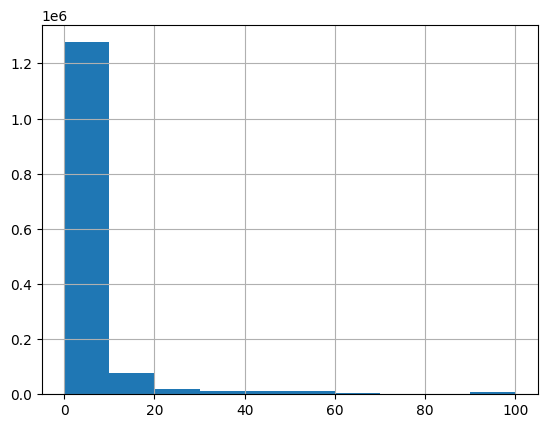

In [52]:
fichier_final_vote['voix_pct'].hist()

In [56]:
fichier_final_vote_ss_2008 = fichier_final_vote[(fichier_final_vote['annee']!= "2008") &
                                                    (fichier_final_vote['voix_pct'] > 50)
]

In [57]:
fichier_final_vote_ss_2008.head()

,id_election,ident_election_ville,Nom,Prénom,Nuance_muni,voix_totales_candidat,voix_total_ville_elec,voix_pct,annee,Région siège,...,Nom Président,prenom,dep,Nuance_interco,nom,insee,siren_membre,dept,siren,raison_sociale
13521,2014_muni_t1,01005,PERNET,Pierre,LDIV,479.0,479.0,100.000000,2014,84 - Auvergne-Rhône-Alpes,...,grison,bernard,01,LDVD,grison,01005,210100053,01,200042497,CC Dombes Saône Vallée
13563,2014_muni_t1,01010,THIBOUD,Bernard,LDVD,292.0,520.0,56.153846,2014,84 - Auvergne-Rhône-Alpes,...,rannard,paul,74,NC,rannard,01010,210100103,74,200070852,CC Usses et Rhône
13604,2014_muni_t1,01014,MAISSIAT,Liliane,LUMP,930.0,930.0,100.000000,2014,84 - Auvergne-Rhône-Alpes,...,deguerry,jean,01,LDVD,deguerry,01014,210100145,01,200042935,CA Haut-Bugey Agglomération
13674,2014_muni_t1,01021,PACCAUD,Richard,LDIV,411.0,726.0,56.611570,2014,84 - Auvergne-Rhône-Alpes,...,grison,bernard,01,LDVD,grison,01021,210100210,01,200042497,CC Dombes Saône Vallée
13676,2014_muni_t1,01022,CHARMONT-MUNET,Mireille,LDVD,386.0,593.0,65.092749,2014,84 - Auvergne-Rhône-Alpes,...,vuillerod,rene,01,NC,vuillerod,01022,210100228,01,200040350,CC Bugey Sud


In [59]:
fichier_final_vote_ss_2008.shape

(18174, 38)

In [63]:
table_code_insee_code_postal = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/correspondance-code-insee-code-postal.csv", sep = ";", dtype='str')
table_code_insee_code_postal = table_code_insee_code_postal[['Code INSEE', 'Code Postal']]

In [ ]:
fichier_vote_avec_code_postal = pd.merge(
fichier_final_vote_ss_2008,
table_code_insee_code_postal,
left_on = 'insee',
right_on = 'Code INSEE'
)

In [65]:
fichier_vote_avec_code_postal.head()

,id_election,ident_election_ville,Nom,Prénom,Nuance_muni,voix_totales_candidat,voix_total_ville_elec,voix_pct,annee,Région siège,...,dep,Nuance_interco,nom,insee,siren_membre,dept,siren,raison_sociale,Code INSEE,Code Postal
0,2014_muni_t1,01005,PERNET,Pierre,LDIV,479.0,479.0,100.000000,2014,84 - Auvergne-Rhône-Alpes,...,01,LDVD,grison,01005,210100053,01,200042497,CC Dombes Saône Vallée,01005,01330
1,2014_muni_t1,01010,THIBOUD,Bernard,LDVD,292.0,520.0,56.153846,2014,84 - Auvergne-Rhône-Alpes,...,74,NC,rannard,01010,210100103,74,200070852,CC Usses et Rhône,01010,01350
2,2014_muni_t1,01014,MAISSIAT,Liliane,LUMP,930.0,930.0,100.000000,2014,84 - Auvergne-Rhône-Alpes,...,01,LDVD,deguerry,01014,210100145,01,200042935,CA Haut-Bugey Agglomération,01014,01100
3,2014_muni_t1,01021,PACCAUD,Richard,LDIV,411.0,726.0,56.611570,2014,84 - Auvergne-Rhône-Alpes,...,01,LDVD,grison,01021,210100210,01,200042497,CC Dombes Saône Vallée,01021,01480
4,2014_muni_t1,01022,CHARMONT-MUNET,Mireille,LDVD,386.0,593.0,65.092749,2014,84 - Auvergne-Rhône-Alpes,...,01,NC,vuillerod,01022,210100228,01,200040350,CC Bugey Sud,01022,01510


### vérifs des données

In [69]:
fichier_vote_avec_code_postal['id_election'].value_counts()

id_election
2020_muni_t1    8505
2014_muni_t1    5342
2020_muni_t2    1841
2014_muni_t2     566
Name: count, dtype: int64

ici nombre de maire élus au premier tour en 2014
https://www.lemonde.fr/les-decodeurs/article/2014/03/24/qui-sont-les-maires-elus-des-le-premier-tour_4388664_4355770.html
Normalement 7606 dans les communes de + de 1000 habitants

In [70]:
fichier_vote_avec_code_postal[
    fichier_vote_avec_code_postal['id_election'] == '2014_muni_t1'
]['Nuance_muni'].value_counts()

Nuance_muni
LDVD    2040
LDVG    1255
LDIV     991
LSOC     272
LUMP     218
LUG      183
LUD      140
LUDI     133
LCOM      44
LMDM      21
LUC       18
LFG       12
NC         6
LVEC       4
LPG        3
LFN        1
LEXD       1
Name: count, dtype: int64

Il en manque

On exporte temporairement un fichier pas clean

In [80]:
fichier_vote_avec_code_postal_clean = fichier_vote_avec_code_postal[['annee',
'ident_election_ville', 'Nuance_muni','voix_pct','Nuance_interco']]

In [81]:
fichier_vote_avec_code_postal_clean[(fichier_vote_avec_code_postal_clean['voix_pct'] < 55)].shape

(3111, 5)

In [82]:
fichier_vote_avec_code_postal_clean.to_csv("/home/onyxia/work/projet3A/donnees_electorales/donnees_muni_epci_completes.csv", index=False)